# What is sales, and what is it made of?

**Week 1, Monday. Round 1 of 3: which total is "sales", and which multiplied branches make it?**

Kalpa Retail grew revenue 4 percent last year against a plan of 15, and marketing has asked for
Rs 12 crore to acquire new customers. Meera Raghavan, the CEO, will not sign yet:

> "Before I sign anything, I want to understand our own sales. What is 'sales' made of? Where does
> revenue come from, by customer type and channel? Is acquisition even the branch that is short?"

> **Kavya's review.** Every number you bring me today carries its definition beside it. "Sales is
> five lakh" is a rumour. "Booked sales on 30 orders, cancellations included" is a number I can take
> into Meera's room.

Before this round the room drew the revenue tree on the board: revenue is customers, times orders
per customer, times average order value, and average order value is items per order times price per
item, less discounts. This round puts the first numbers on that tree. It settles which total deserves
the word "sales" and turns each branch into a metric with a numerator and a denominator.

**Setup.** The first cell finds the shared helper, `c2kit`, by walking up from this folder until it
reaches `scripts/`, then loads the 30 orders from `../data/` as a list of dictionaries named
`ORDERS`. Run it first, and run it again after any kernel restart.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()
first_day = min(order["order_date"] for order in ORDERS)
last_day = max(order["order_date"] for order in ORDERS)
print(len(ORDERS), "orders loaded, dated", first_day, "to", last_day)

30 orders loaded, dated 2026-07-01 to 2026-09-26


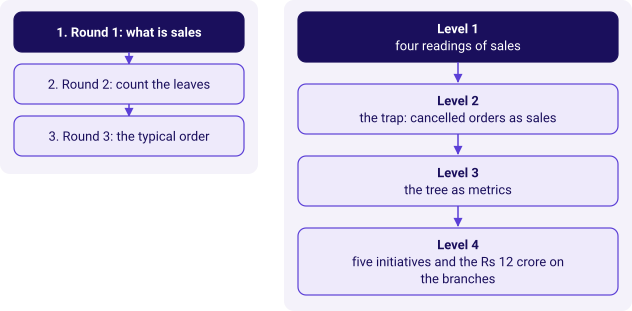

In [2]:
kit.side_by_side(
    kit.ladder(["Round 1: what is sales", "Round 2: count the leaves", "Round 3: the typical order"],
               lit=0, show=False),
    kit.vflow(["Level 1\nfour readings of sales",
               "Level 2\nthe trap: cancelled orders as sales",
               "Level 3\nthe tree as metrics",
               "Level 4\nfive initiatives and the Rs 12 crore on the branches"], lit=0, show=False),
)

## 1. "Sales" has four readings, and each gives a different number

One Kalpa order is a dictionary: seven named fields, each reached by its name. The whole extract is
a list of 30 such dictionaries, one per order, which is why a loop can visit each order and an `if`
can decide what to do with it. The field that splits the readings of "sales" is `status`: an order
can be delivered, returned after delivery, or cancelled before it ever left.

In [3]:
first = ORDERS[0]
kit.table(["key", "value", "what it answers"],
          [("order_id", first["order_id"], "which order, one row each"),
           ("customer_id", first["customer_id"], "who bought, which is how customers are counted"),
           ("segment", first["segment"], "which kind of customer placed it"),
           ("channel", first["channel"], "where it was placed: app, web or store"),
           ("order_date", first["order_date"], "when, inside the quarter's window"),
           ("amount", first["amount"], "for how much, in rupees"),
           ("status", first["status"], "whether it stayed sold")],
          caption="ORDERS[0], one Kalpa order as a dictionary")

key,value,what it answers
order_id,KR-01001,"which order, one row each"
customer_id,C-0101,"who bought, which is how customers are counted"
segment,Retail-Core,which kind of customer placed it
channel,app,"where it was placed: app, web or store"
order_date,2026-07-21,"when, inside the quarter's window"
amount,2300,"for how much, in rupees"
status,delivered,whether it stayed sold


The loop below reads every order once and keeps four totals: how many orders there are, and three
sums of rupees. Every amount passes through `int()`, which turns a value into a whole number;
round 2 takes the `int()` away and shows what it guards against.

**Predict before you run.** Which of the three rupee readings comes out largest?

- a) Delivered, because only delivered orders are real sales.
- b) Not cancelled, because it keeps the returns as well as the deliveries.
- c) Booked, because it adds every order whatever happened to it.
- d) All three are equal, because every order in the extract was paid for.

reading of sales,what it keeps,value
order count,every row in the extract,30
booked,every order placed,"Rs 5,44,810"
not cancelled,"orders that left the shelf, returns included","Rs 5,35,760"
delivered,orders that reached the customer and stayed,"Rs 5,20,790"


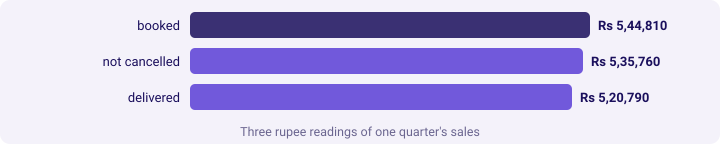

In [4]:
readings = {"orders": 0, "booked": 0, "not cancelled": 0, "delivered": 0}
for order in ORDERS:
    amount = int(order["amount"])
    readings["orders"] += 1
    readings["booked"] += amount
    if order["status"] != "cancelled":
        readings["not cancelled"] += amount
    if order["status"] == "delivered":
        readings["delivered"] += amount

kit.table(["reading of sales", "what it keeps", "value"],
          [("order count", "every row in the extract", readings["orders"]),
           ("booked", "every order placed", kit.rupees(readings["booked"])),
           ("not cancelled", "orders that left the shelf, returns included", kit.rupees(readings["not cancelled"])),
           ("delivered", "orders that reached the customer and stayed", kit.rupees(readings["delivered"]))],
          caption="Four readings of 'sales' on the same 30 orders")
kit.bars([("booked", readings["booked"]), ("not cancelled", readings["not cancelled"]),
          ("delivered", readings["delivered"])],
         fmt=kit.rupees, lit=(0,), title="Three rupee readings of one quarter's sales")

**What happened.** The answer is c. Booked sales is Rs 5,44,810, not cancelled is Rs 5,35,760 and
delivered is Rs 5,20,790. The three sit within Rs 24,020 of each other, which is small against the
total and large against a growth target: a 15 percent plan built on the wrong base starts from a
number Kalpa never collected. The order count, 30, is a fourth reading and answers a different
question, how many times somebody decided to buy.

In [5]:
kit.check("the loop visited all 30 orders", readings["orders"] == 30, readings["orders"])
kit.check("booked sales is Rs 5,44,810", readings["booked"] == 544810, kit.rupees(readings["booked"]))
kit.check("each narrower definition keeps less",
          readings["booked"] >= readings["not cancelled"] >= readings["delivered"],
          f'{kit.rupees(readings["booked"])} >= {kit.rupees(readings["not cancelled"])} >= {kit.rupees(readings["delivered"])}')

## 2. The trap: cancelled orders reported as sales

The fastest answer to "what are our sales?" is to add every amount in the file and send the total.
It is also the answer most first-week analysts send, because the file looks like a list of sales.

**Predict before you run.** Of the 30 orders in that total, how many never became a sale at all?

- a) None, since every row is an order someone placed.
- b) Nine, the returns and the cancellations together.
- c) Five, the orders that came back.
- d) Four, the orders cancelled before they left.

**The plausible wrong answer.** The hurried analyst's cell, exactly as it would be written:

In [6]:
sales = 0
for order in ORDERS:
    sales += int(order["amount"])
print("Sales this quarter:", kit.rupees(sales), "on", len(ORDERS), "orders")

Sales this quarter: Rs 5,44,810 on 30 orders


**Why it is wrong.** A cancelled order never left the shelf and never paid Kalpa a rupee, so it is
demand that never arrived. Reported as sales, it overstates the base that Meera's 15 percent growth
plan is measured from, and it overstates the channel it sits in. The check below counts orders by
status before summing anything, then asks where the cancellations happened.

status,orders
delivered,21
returned,5
cancelled,4


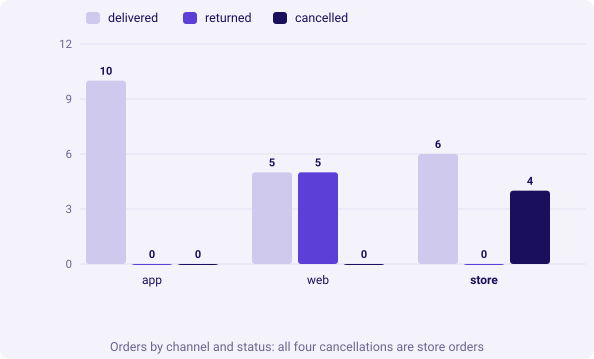

In [7]:
by_status = {}
for order in ORDERS:
    by_status[order["status"]] = by_status.get(order["status"], 0) + 1

grid = {}
for order in ORDERS:
    key = (order["channel"], order["status"])
    grid[key] = grid.get(key, 0) + 1

channels = ["app", "web", "store"]
kit.table(["status", "orders"], [(s, by_status[s]) for s in ["delivered", "returned", "cancelled"]],
          caption="Count the statuses before you add the amounts")
kit.columns(channels,
            [(status, [grid.get((ch, status), 0) for ch in channels])
             for status in ["delivered", "returned", "cancelled"]],
            lit=(2,), title="Orders by channel and status: all four cancellations are store orders")

In [8]:
cancelled_channels = set()
for order in ORDERS:
    if order["status"] == "cancelled":
        cancelled_channels.add(order["channel"])
kit.check("the statuses split 21 delivered, 5 returned, 4 cancelled",
          (by_status["delivered"], by_status["returned"], by_status["cancelled"]) == (21, 5, 4), by_status)
kit.check("every cancelled order is a store order", cancelled_channels == {"store"}, cancelled_channels)
kit.check("the wrong total counts cancelled orders as sales", sales == readings["booked"] > readings["not cancelled"],
          f"{kit.rupees(sales)} against {kit.rupees(readings['not cancelled'])}")

**What happened.** The answer is d. Four orders were cancelled, and all four were placed in a store,
so store's 10 orders overstate its sales by 4 in 10. The five returns are a different case: they did
become sales and then came back, which is why they stay in "not cancelled" and leave "delivered".

**The fix.** State the definition beside the number. The bridge below walks from booked to
delivered, one definition at a time, so every rupee that leaves is named.

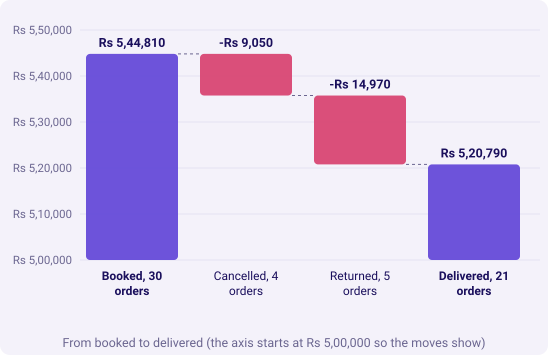

Not cancelled: Rs 5,35,760 on 26 orders
Delivered: Rs 5,20,790 on 21 orders


In [9]:
kit.bridge(("Booked, 30 orders", readings["booked"]),
           [("Cancelled, 4 orders", readings["not cancelled"] - readings["booked"]),
            ("Returned, 5 orders", readings["delivered"] - readings["not cancelled"])],
           end_label="Delivered, 21 orders", lo=500000,
           title="From booked to delivered (the axis starts at Rs 5,00,000 so the moves show)")
for name, orders, rupees in [("Not cancelled", 26, readings["not cancelled"]),
                             ("Delivered", 21, readings["delivered"])]:
    print(f"{name}: {kit.rupees(rupees)} on {orders} orders")
kit.check("booked less cancelled less returned lands on delivered",
          readings["booked"] - 9050 - 14970 == readings["delivered"], kit.rupees(readings["delivered"]))
kit.check("not cancelled is Rs 5,35,760", readings["not cancelled"] == 535760, kit.rupees(readings["not cancelled"]))

What changed: taking the cancellations out moves Rs 9,050 and 4 orders out of sales, all of them from
the store channel; taking the returns out as well moves another Rs 14,970 and 5 orders, all of them
web orders. The sentence for Meera names the definition first: "Sales this quarter, net of
cancellations, were Rs 5,35,760 on 26 orders; Rs 5,20,790 on 21 orders stayed delivered."

> **Kavya's review.** You found Rs 9,050 that was never a sale, and you found it by counting before
> adding. That is the habit. Which definition Meera wants is her call; your job is to make sure she
> can see which one she is looking at.

## 3. The tree turns each branch into a metric with a numerator and a denominator

A branch is only useful when it can be measured, and a measure is a numerator over a denominator.
Orders per customer is orders divided by distinct customers; average order value is revenue
divided by orders. Some branches cannot be measured from this extract at all, and saying so is part
of the answer, because it tells Meera what data she would have to ask for.

**Predict before you run.** Booked revenue is split into orders times average order value. What does
multiplying the two back together give?

- a) Exactly booked revenue, Rs 5,44,810, because the average was made from that total.
- b) More than booked revenue, because repeat customers are counted twice.
- c) Less than booked revenue, because the average rounds down.
- d) Nothing useful until prices per item are known.

branch,numerator,denominator,in this extract
customers,distinct customer ids,"none, it is a count","measurable, round 2 counts it"
orders per customer,orders,distinct customers,"measurable, round 2"
average order value,revenue,orders,"Rs 18,160"
items per order,items sold,orders,not in this extract
price per item,revenue before discounts,items sold,not in this extract
discount rate,rupees discounted,revenue before discounts,not in this extract


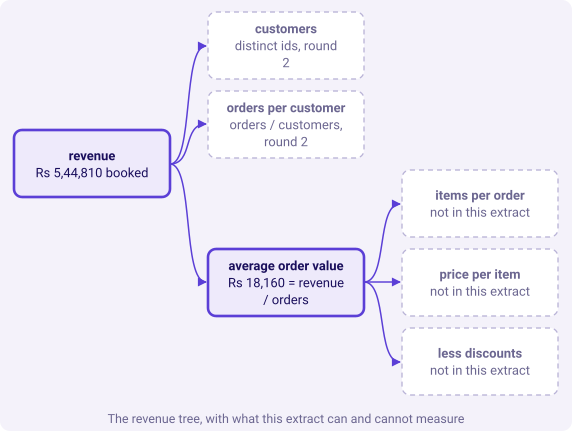

In [10]:
orders = readings["orders"]
revenue = readings["booked"]
average_order_value = revenue / orders

kit.table(["branch", "numerator", "denominator", "in this extract"],
          [("customers", "distinct customer ids", "none, it is a count", "measurable, round 2 counts it"),
           ("orders per customer", "orders", "distinct customers", "measurable, round 2"),
           ("average order value", "revenue", "orders", kit.rupees(average_order_value)),
           ("items per order", "items sold", "orders", "not in this extract"),
           ("price per item", "revenue before discounts", "items sold", "not in this extract"),
           ("discount rate", "rupees discounted", "revenue before discounts", "not in this extract")],
          caption="Every branch as a metric, booked definition")
kit.driver_tree({"label": "revenue", "note": kit.rupees(revenue) + " booked", "kind": "known", "children": [
    {"label": "customers", "note": "distinct ids, round 2", "kind": "unknown"},
    {"label": "orders per customer", "note": "orders / customers, round 2", "kind": "unknown"},
    {"label": "average order value", "note": kit.rupees(average_order_value) + " = revenue / orders", "kind": "known",
     "children": [{"label": "items per order", "note": "not in this extract", "kind": "unknown"},
                  {"label": "price per item", "note": "not in this extract", "kind": "unknown"},
                  {"label": "less discounts", "note": "not in this extract", "kind": "unknown"}]}]},
    title="The revenue tree, with what this extract can and cannot measure")

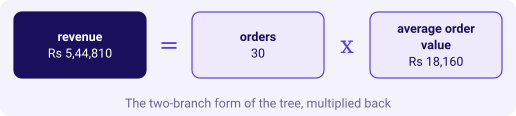

In [11]:
kit.equation(["revenue\n" + kit.rupees(orders * average_order_value), "=", "orders\n30", "x",
              "average order value\n" + kit.rupees(average_order_value)],
             title="The two-branch form of the tree, multiplied back")
kit.check("orders times average order value lands on booked revenue",
          round(orders * average_order_value) == 544810, kit.rupees(orders * average_order_value))
kit.check("average order value on the booked definition is Rs 18,160",
          round(average_order_value) == 18160, kit.rupees(average_order_value))

**What happened.** The answer is a. The average was made by dividing booked revenue by 30, so
multiplying by 30 has to give the total back. That is the strength of the tree and its limit: the
product always lands on revenue, so a wrong leaf never shows in the total and only shows in the
split. Round 2 fills the two customer branches, and round 3 asks whether Rs 18,160 describes an
order anybody at Kalpa would recognise.

## 4. Every initiative sits on one branch, and each branch costs something different to move

Marketing's Rs 12 crore is a bet on the customers branch. The room's harder variant places five
other ideas on the tree and names what each would cost, so that Meera compares bets on branches
rather than on slogans.

**Predict before you run.** A 15 percent discount lifts the quantity sold by 10 percent. What
happens to revenue?

- a) It rises about 10 percent, because more is sold.
- b) It stays flat, because the two effects cancel.
- c) It falls 5 percent, because 10 minus 15 is minus 5.
- d) It falls 6.5 percent, because the two changes multiply.

initiative,the branch it moves,what moving it costs
a discount,"price per item, less discounts",margin traded for quantity
a new store,customers,"rent, staff and stock before the first sale"
a loyalty card,orders per customer,rewards and retention spend
a price rise,price per item,"volume, if customers walk away"
an app redesign,orders per customer,"engineering time, repaid only by repeat buying"
marketing's Rs 12 crore,customers,acquisition spend


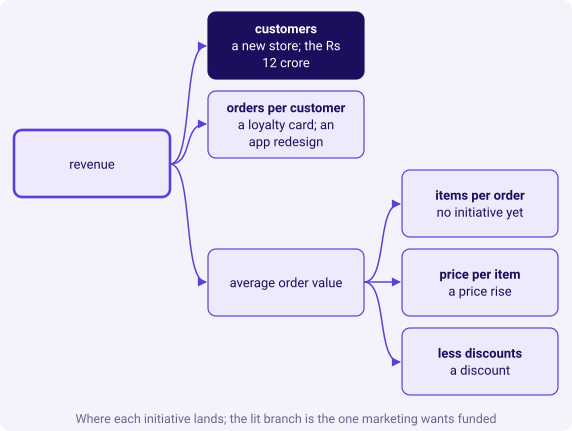

In [12]:
initiatives = [
    ("a discount", "price per item, less discounts", "margin traded for quantity"),
    ("a new store", "customers", "rent, staff and stock before the first sale"),
    ("a loyalty card", "orders per customer", "rewards and retention spend"),
    ("a price rise", "price per item", "volume, if customers walk away"),
    ("an app redesign", "orders per customer", "engineering time, repaid only by repeat buying"),
    ("marketing's Rs 12 crore", "customers", "acquisition spend"),
]
kit.table(["initiative", "the branch it moves", "what moving it costs"], initiatives,
          caption="Six bets placed on the tree")
kit.driver_tree({"label": "revenue", "kind": "known", "children": [
    {"label": "customers", "note": "a new store; the Rs 12 crore", "kind": "lit"},
    {"label": "orders per customer", "note": "a loyalty card; an app redesign"},
    {"label": "average order value", "children": [
        {"label": "items per order", "note": "no initiative yet"},
        {"label": "price per item", "note": "a price rise"},
        {"label": "less discounts", "note": "a discount"}]}]},
    title="Where each initiative lands; the lit branch is the one marketing wants funded")

price x 0.85, quantity x 1.10, revenue x 0.935
revenue changes by -6.5 percent


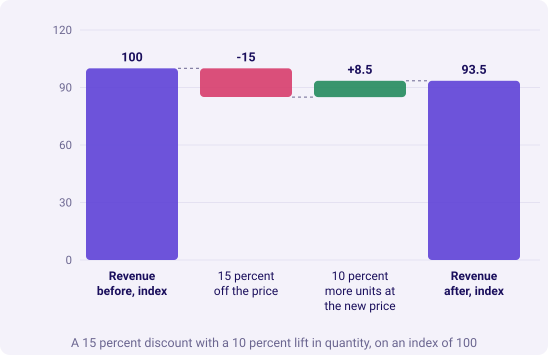

In [13]:
price_factor = 1 - 0.15
quantity_factor = 1 + 0.10
revenue_factor = price_factor * quantity_factor
print(f"price x {price_factor:.2f}, quantity x {quantity_factor:.2f}, revenue x {revenue_factor:.3f}")
print(f"revenue changes by {(revenue_factor - 1) * 100:.1f} percent")
kit.bridge(("Revenue before, index", 100),
           [("15 percent off the price", -15), ("10 percent more units at the new price", 8.5)],
           end_label="Revenue after, index", fmt=lambda v: f"{v:g}",
           title="A 15 percent discount with a 10 percent lift in quantity, on an index of 100")

**What happened.** The answer is d. The price falls to 0.85 of itself and the quantity rises to 1.10
of itself, and revenue is their product, 0.935, a fall of 6.5 percent. Option c adds percentages,
which is the mistake the afternoon's escalated case sets up at a larger scale. For Meera, a discount
is a bet that loses revenue unless quantity rises by more than it looks as if it needs to.

In [14]:
kit.check("the discount's revenue factor is 0.935", abs(revenue_factor - 0.935) < 1e-9, f"{revenue_factor:.3f}")
kit.check("revenue falls 6.5 percent", round((1 - revenue_factor) * 100, 1) == 6.5,
          f"{(1 - revenue_factor) * 100:.1f} percent")
branches = set()
for _, branch, _ in initiatives:
    branches.add(branch)
kit.check("the six initiatives land on at least four different branches", len(branches) >= 4, sorted(branches))

### In the interview

**[S] How would you increase sales for an online retailer?** "I would draw the revenue tree before
suggesting anything: customers, times orders per customer, times average order value, and average
order value as items per order times price, less discounts. Then I would measure each branch on the
same window and ask which one is short against plan, because each costs something different to move:
acquisition costs marketing, frequency costs retention, basket costs merchandising, price risks
volume and discounts trade margin for quantity. Only after that would I name initiatives, and I
would place each one on the branch it moves."

**[F] A business says 'grow revenue 15 percent'; how do you turn that into questions data can
answer?** "First, 15 percent of which revenue: booked, net of cancellations or delivered, over which
window, against which base period. Then I break the target down the tree and ask which branch has
to move and by how much, for example how many customers, how many orders each, at what order value.
Each of those is a numerator over a denominator I can compute, and each one maps to a team that
owns it."

**[F] What counts as "sales": booked, net of cancellations, or delivered, and which do you give a
CEO?** "All three are legitimate and they answer different questions. Booked is demand, net of
cancellations is what left the shelf, delivered is what stayed sold. On Kalpa's quarter they were
Rs 5,44,810, Rs 5,35,760 and Rs 5,20,790. I would give the CEO the definition her plan was set on,
say it beside the number, and show the bridge between them so the gaps are named rather than
hidden."

**[D] A 15 percent discount lifts quantity 10 percent; did revenue rise or fall, and what would you
ask next?** "It fell 6.5 percent, because revenue is price times quantity and 0.85 times 1.10 is
0.935. Next I would ask whether the discount brought new customers or pulled forward purchases that
would have happened anyway, what it did to margin, and whether the lift lasted past the sale."

### Depth: how much must quantity rise for a discount to break even?

Revenue stays flat when the quantity factor exactly offsets the price factor, which means quantity
has to rise by 1 divided by 0.85, less one. The line below walks the quantity lift from zero to 25
percent and marks where the discounted revenue crosses the undiscounted line.

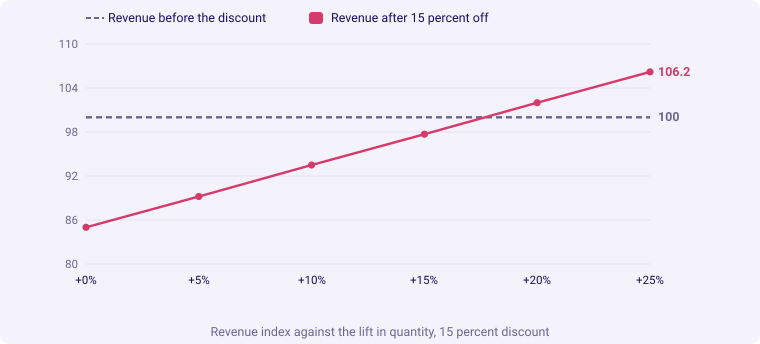

quantity must rise 17.6 percent before a 15 percent discount stops losing revenue


In [15]:
lifts = [0, 5, 10, 15, 20, 25]
after = [round(100 * 0.85 * (1 + lift / 100), 1) for lift in lifts]
kit.line([f"+{lift}%" for lift in lifts],
         [("Revenue before the discount", [100] * len(lifts), "plan"),
          ("Revenue after 15 percent off", after, "bad")],
         fmt=lambda v: f"{v:g}", lo=80,
         title="Revenue index against the lift in quantity, 15 percent discount")
break_even = (1 / 0.85 - 1) * 100
print(f"quantity must rise {break_even:.1f} percent before a 15 percent discount stops losing revenue")
kit.check("the break-even lift is about 17.6 percent", round(break_even, 1) == 17.6, f"{break_even:.1f}")

A 15 percent discount needs about 17.6 percent more units just to stand still on revenue, and more
than that to stand still on margin, since every one of those extra units is sold for less. That is
why "the discount worked, volume is up 10 percent" is a sentence to question rather than to
celebrate.

## What this round established

What we now know,The evidence
"Sales has four readings, and the definition goes beside the number","30 orders; Rs 5,44,810 booked, Rs 5,35,760 not cancelled, Rs 5,20,790 delivered"
"Cancelled orders are demand that never arrived, and all four sit in store","Rs 9,050 on 4 store orders"
"Each branch is a numerator over a denominator, and three are not in this extract","average order value Rs 18,160 = Rs 5,44,810 / 30"
Lifts along the tree multiply,"0.85 x 1.10 = 0.935, a 6.5 percent fall"


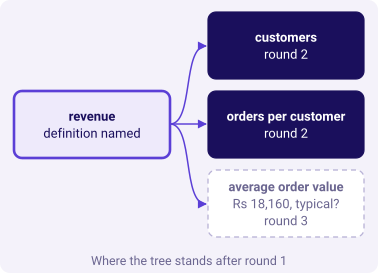

In [16]:
kit.table(["What we now know", "The evidence"],
          [("Sales has four readings, and the definition goes beside the number",
            "30 orders; Rs 5,44,810 booked, Rs 5,35,760 not cancelled, Rs 5,20,790 delivered"),
           ("Cancelled orders are demand that never arrived, and all four sit in store",
            "Rs 9,050 on 4 store orders"),
           ("Each branch is a numerator over a denominator, and three are not in this extract",
            "average order value Rs 18,160 = Rs 5,44,810 / 30"),
           ("Lifts along the tree multiply", "0.85 x 1.10 = 0.935, a 6.5 percent fall")],
          caption="Round 1: what sales is, and what it is made of")
kit.driver_tree({"label": "revenue", "note": "definition named", "kind": "known", "children": [
    {"label": "customers", "note": "round 2", "kind": "lit"},
    {"label": "orders per customer", "note": "round 2", "kind": "lit"},
    {"label": "average order value", "note": "Rs 18,160, typical? round 3", "kind": "unknown"}]},
    title="Where the tree stands after round 1")

In [17]:
kit.check_summary()
print("Next: round 2 counts the leaves, customers and orders per customer, and meets the first "
      "thing a real file does to a clean loop.")

Next: round 2 counts the leaves, customers and orders per customer, and meets the first thing a real file does to a clean loop.
